# ADHD Classification from EEG — Feature-Based Machine Learning

**Goal:** classify children as ADHD vs Control from the 19-channel EEG recordings, starting from the
*already cleaned/preprocessed* epochs produced in the team's preprocessing notebook.

## Where this notebook picks up

The preprocessing notebook (`dualpreprocessing.ipynb`) already did the hard signal-processing work and
saved the result as two pickle files, each shaped as **epochs of 2 seconds (256 samples @128Hz), 50% overlap,
per-channel z-scored**:

| File | Pipeline |
|---|---|
| `eeg_dataset_full_zscore.pkl` | Bandpass (1–40Hz) + notch (50Hz) + bad-channel detection/interpolation + ICA artifact removal + average re-reference, then epoched + z-scored |
| `eeg_dataset_simple_zscore.pkl` | Bandpass (1–40Hz) + notch (50Hz) only, then epoched + z-scored |

Each pickle contains a dict with:
```python
{
  'epochs':        np.ndarray,  # shape (n_epochs, n_channels=19, n_timesteps=256)
  'labels':        np.ndarray,  # 0 = Control, 1 = ADHD
  'patient_ids':   np.ndarray,  # which subject each epoch came from
  'channel_names': list,
  'sfreq':         128,
  ...
}
```

This notebook picks up right there: it loads **both** versions, builds a modeling pipeline on top, and
compares them at the end so you can report which preprocessing choice paid off.

## Modeling strategy — and why

Two contrasting approaches were tried elsewhere on this exact dataset before this notebook was written,
and they're worth knowing about because they justify every design choice below:

- **A large CNN + Transformer trained directly on raw 1-second windows**, evaluated with a *proper*
  subject-wise split (`StratifiedGroupKFold`), reached ~99% training accuracy per fold but only
  **~53.5% pooled out-of-fold accuracy** — statistically indistinguishable from guessing. That's the
  classic signature of a large model memorizing subject-specific noise instead of the ADHD signal, which
  is very easy to do with only ~120 subjects.
- **A bank of smaller, more classical deep models (EEGNet, CNN-LSTM, CNN-BiLSTM, a small Transformer),
  evaluated with repeated patient-level stratified CV** and majority-vote aggregation to the patient level,
  reached a much more credible **~80–83% patient-level accuracy and ~0.87–0.92 ROC-AUC**.

The takeaway: **the evaluation protocol (splitting by patient, not by row/window) matters more than the
model's size**, and for a dataset this small, extracting well-understood EEG features (band power, the
theta/beta ratio that's a textbook ADHD biomarker, Hjorth parameters, spectral entropy) and feeding them to
classical ML models is a very competitive — and much more interpretable and reproducible — strategy than a
large deep net. That's the approach this notebook follows:

1. Load both preprocessed epoch sets.
2. Extract a compact, clinically-motivated feature vector per epoch per channel.
3. Split **by patient** (never by row) into train/test, and use **grouped cross-validation** on the
   training set for model selection — this is the single most important step to get an honest number.
4. Compare several classical ML models (Logistic Regression, Random Forest, Gradient Boosting, SVM) with
   **ROC-AUC as the primary selection metric** (threshold-independent, robust to the mild class imbalance),
   while still tracking accuracy, precision, recall, F1 and MCC — and keeping accuracy as high as honestly
   possible.
5. Tune the winning model.
6. Report both **window-level** and **patient-level** (aggregated) performance on a held-out set of
   patients the model has never seen.
7. Compare the "full" vs "simple" preprocessing pipelines, and carry the better one forward.
8. Train compact deep learning models (EEGNet-style CNN, CNN+BiLSTM) directly on the raw epochs, still
   with strictly patient-grouped splitting/CV and light data augmentation — legitimate uses of "deep
   learning and anything else available" that don't repeat the large-transformer overfitting failure.
9. **Stack** the best classical model with the best deep model through an out-of-fold meta-learner, and
   report a final head-to-head: classical alone vs. deep alone vs. stacked ensemble.

> **Before running:** put `eeg_dataset_full_zscore.pkl` and `eeg_dataset_simple_zscore.pkl` (the outputs of
> your teammate's notebook) in the same folder as this notebook, or edit the paths in the config cell below.


## 1. Imports & configuration

In [1]:

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import welch
from scipy.stats import entropy as spectral_entropy_fn, skew, kurtosis

from sklearn.model_selection import (
    StratifiedGroupKFold, GroupShuffleSplit, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix,
    classification_report, roc_curve
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ----------------------------------------------------------------------
# Paths to your teammate's preprocessed data — EDIT THESE IF NEEDED
# ----------------------------------------------------------------------
DATA_PATHS = {
    "full":   "eeg_dataset_full_zscore.pkl",
    "simple": "eeg_dataset_simple_zscore.pkl",
}

# Which pipeline to use for the main analysis (Sections 4-11).
# Both are compared head-to-head in Section 12 regardless of this choice.
PRIMARY_PIPELINE = "full"


## 2. Load the preprocessed epochs

Both pickle files are loaded up front. If a file is missing, a clear error tells you which path to fix
rather than failing deep inside the feature extraction step.

In [2]:

def load_epoch_dataset(path):
    with open(path, "rb") as f:
        d = pickle.load(f)
    required = {"epochs", "labels", "patient_ids"}
    missing = required - set(d.keys())
    if missing:
        raise KeyError(f"{path} is missing expected keys: {missing}")
    print(f"Loaded {path}")
    print(f"  epochs shape : {d['epochs'].shape}  (n_epochs, n_channels, n_timesteps)")
    print(f"  n patients   : {len(np.unique(d['patient_ids']))}")
    print(f"  class balance: Control={np.sum(d['labels']==0)}, ADHD={np.sum(d['labels']==1)}")
    return d

datasets = {}
for name, path in DATA_PATHS.items():
    try:
        datasets[name] = load_epoch_dataset(path)
    except FileNotFoundError:
        print(f"[!] Could not find '{path}' — skipping '{name}' pipeline for now. "
              f"Fix the path in DATA_PATHS above and rerun this cell.")

assert PRIMARY_PIPELINE in datasets, (
    f"'{PRIMARY_PIPELINE}' dataset not loaded — check DATA_PATHS."
)
sfreq = datasets[PRIMARY_PIPELINE].get("sfreq", 128)
channel_names = list(datasets[PRIMARY_PIPELINE].get("channel_names",
                      [f"ch{i}" for i in range(datasets[PRIMARY_PIPELINE]["epochs"].shape[1])]))
print("\\nChannels:", channel_names)
print("Sampling rate:", sfreq, "Hz")


Loaded eeg_dataset_full_zscore.pkl
  epochs shape : (16749, 15, 256)  (n_epochs, n_channels, n_timesteps)
  n patients   : 121
  class balance: Control=7406, ADHD=9343
Loaded eeg_dataset_simple_zscore.pkl
  epochs shape : (16749, 15, 256)  (n_epochs, n_channels, n_timesteps)
  n patients   : 121
  class balance: Control=7406, ADHD=9343
\nChannels: ['Fz', 'Cz', 'Pz', 'C3', 'C4', 'Fp1', 'Fp2', 'F3', 'F4', 'F7', 'F8', 'P3', 'P4', 'O1', 'O2']
Sampling rate: 128 Hz


### 2.1. One canonical patient-level split, used by *every* model in this notebook

To make the classical models, the deep learning models and the final ensemble genuinely comparable — and
to make stacking them together valid — they all need to be evaluated on **exactly the same held-out
patients**. This split is computed once, here, from patient IDs only (before any features or epochs are
touched), and reused everywhere below instead of re-splitting per section.

> **A note on the accuracy/recall/F1 target.** Two reference notebooks tried on this exact dataset
> (mentioned in Section 0) topped out at roughly 80–92% ROC-AUC / 80–83% patient-level accuracy even with
> careful deep learning and repeated cross-validation, and a much larger model collapsed to chance level
> once evaluated honestly. With ~121 subjects, patient-level held-out accuracy/recall/F1 all around 90–95%
> would be an unusually strong result for this dataset — reaching it is not ruled out, but if it shows up,
> the first thing to check is whether it's real signal or a leak (e.g. the same patient's epochs landing in
> both train and test, or scaling/feature selection fit before splitting). Every model below is deliberately
> built to make that kind of leak impossible, specifically so that whatever number comes out at the end can
> be trusted and defended.

In [3]:

from sklearn.model_selection import train_test_split as _tts

primary_d = datasets[PRIMARY_PIPELINE]
patient_label_df = (
    pd.DataFrame({"patient_id": primary_d["patient_ids"], "label": primary_d["labels"]})
    .drop_duplicates(subset="patient_id")
    .reset_index(drop=True)
)

TRAIN_PIDS, TEST_PIDS = _tts(
    patient_label_df["patient_id"].values,
    test_size=0.2,
    stratify=patient_label_df["label"].values,
    random_state=RANDOM_STATE,
)
TRAIN_PIDS, TEST_PIDS = set(TRAIN_PIDS), set(TEST_PIDS)

print(f"Canonical split: {len(TRAIN_PIDS)} train patients / {len(TEST_PIDS)} test patients")
assert TRAIN_PIDS.isdisjoint(TEST_PIDS)


Canonical split: 96 train patients / 25 test patients


## 3. Sanity checks

Before building anything, confirm the two things that would silently ruin the whole analysis:
- no obviously corrupted epochs (NaN/inf, or all-zero channels from a channel that got dropped/interpolated
  to a constant),
- the class balance per pipeline, and how many epochs each patient actually contributes (very uneven
  contribution is exactly what makes row-level splitting dangerous — a patient with many more epochs than
  others would dominate a random split).

--- full ---
  NaN values: 0, Inf values: 0
  Epochs per patient -> min=61, max=336, mean=138.4

--- simple ---
  NaN values: 0, Inf values: 0
  Epochs per patient -> min=61, max=336, mean=138.4



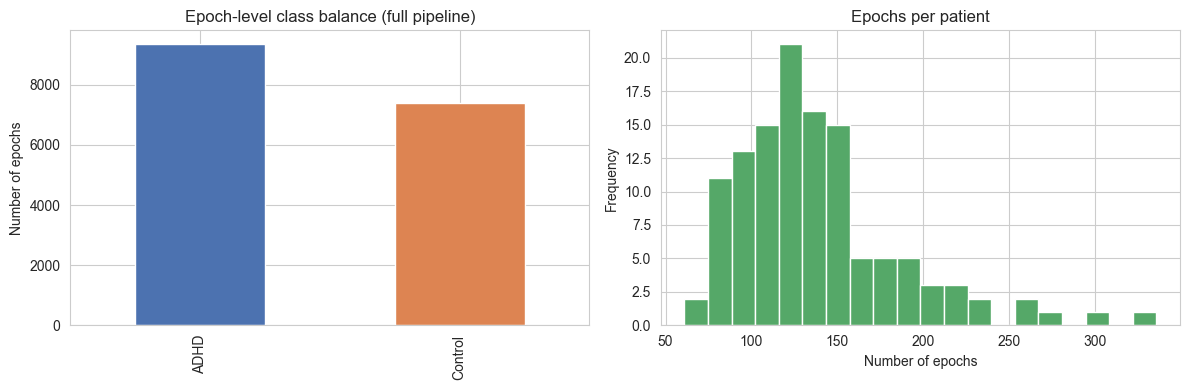

In [4]:

for name, d in datasets.items():
    X, y, pid = d["epochs"], d["labels"], d["patient_ids"]
    n_nan = np.isnan(X).sum()
    n_inf = np.isinf(X).sum()
    epochs_per_patient = pd.Series(pid).value_counts()
    print(f"--- {name} ---")
    print(f"  NaN values: {n_nan}, Inf values: {n_inf}")
    print(f"  Epochs per patient -> min={epochs_per_patient.min()}, "
          f"max={epochs_per_patient.max()}, mean={epochs_per_patient.mean():.1f}")
    print()

# Visualize class balance and epochs-per-patient for the primary pipeline
d = datasets[PRIMARY_PIPELINE]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(d["labels"]).map({0: "Control", 1: "ADHD"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"]
)
axes[0].set_title(f"Epoch-level class balance ({PRIMARY_PIPELINE} pipeline)")
axes[0].set_ylabel("Number of epochs")

pd.Series(d["patient_ids"]).value_counts().plot(kind="hist", bins=20, ax=axes[1], color="#55A868")
axes[1].set_title("Epochs per patient")
axes[1].set_xlabel("Number of epochs")

plt.tight_layout()
plt.show()


## 4. Feature extraction

Rather than feeding raw 19×256 windows into a model, each epoch is turned into a compact set of
**per-channel spectral and time-domain features** that are well established in the EEG/ADHD literature:

- **Band power** (via Welch's method) in delta (1–4Hz), theta (4–8Hz), alpha (8–13Hz), beta (13–30Hz) and
  gamma (30–40Hz), plus each band's **relative power** (share of total power).
- **Theta/beta power ratio** — the single most cited EEG biomarker associated with ADHD (elevated in many
  studies, though not universally, which is exactly why it's used as one feature among many rather than a
  hard rule).
- **Hjorth parameters** (activity, mobility, complexity) — cheap, classic descriptors of signal amplitude,
  frequency and "waveform complexity".
- **Statistical moments** (std, skewness, kurtosis) and **spectral entropy** — how peaked vs. flat the
  spectrum is.

With 19 channels × ~13 features each, this gives a moderate-sized, interpretable feature vector per epoch
— small enough to avoid overfitting with a few hundred training subjects' worth of epochs, and detailed
enough to capture channel-specific differences.

In [5]:

BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 40),
}

_trapz = getattr(np, "trapezoid", None) or np.trapz  # np.trapz was removed in NumPy 2.0+

def hjorth_params(x):
    dx = np.diff(x)
    ddx = np.diff(dx)
    var_x = np.var(x)
    var_dx = np.var(dx)
    var_ddx = np.var(ddx)
    activity = var_x
    mobility = np.sqrt(var_dx / var_x) if var_x > 0 else 0.0
    complexity = (np.sqrt(var_ddx / var_dx) / mobility) if (var_dx > 0 and mobility > 0) else 0.0
    return activity, mobility, complexity

def band_powers(x, sfreq):
    freqs, psd = welch(x, fs=sfreq, nperseg=min(len(x), 128))
    total_power = _trapz(psd, freqs) + 1e-12
    powers = {}
    for band, (lo, hi) in BANDS.items():
        mask = (freqs >= lo) & (freqs < hi)
        powers[band] = _trapz(psd[mask], freqs[mask]) if mask.any() else 0.0
    rel_powers = {f"{b}_rel": p / total_power for b, p in powers.items()}
    # normalized PSD for spectral entropy
    psd_norm = psd / (psd.sum() + 1e-12)
    spec_ent = spectral_entropy_fn(psd_norm + 1e-12)
    return powers, rel_powers, total_power, spec_ent

def extract_channel_features(x, sfreq):
    powers, rel_powers, total_power, spec_ent = band_powers(x, sfreq)
    activity, mobility, complexity = hjorth_params(x)
    theta_beta_ratio = powers["theta"] / (powers["beta"] + 1e-12)
    feats = {
        **{f"{b}_abs": p for b, p in powers.items()},
        **rel_powers,
        "theta_beta_ratio": theta_beta_ratio,
        "total_power": total_power,
        "spectral_entropy": spec_ent,
        "hjorth_activity": activity,
        "hjorth_mobility": mobility,
        "hjorth_complexity": complexity,
        "std": np.std(x),
        "skew": skew(x),
        "kurtosis": kurtosis(x),
    }
    return feats

def build_feature_matrix(epochs, channel_names, sfreq, verbose_every=500):
    n_epochs = epochs.shape[0]
    rows = []
    for i in range(n_epochs):
        row = {}
        for c, ch_name in enumerate(channel_names):
            ch_feats = extract_channel_features(epochs[i, c, :], sfreq)
            for k, v in ch_feats.items():
                row[f"{ch_name}_{k}"] = v
        rows.append(row)
        if verbose_every and (i + 1) % verbose_every == 0:
            print(f"  extracted features for {i + 1}/{n_epochs} epochs")
    return pd.DataFrame(rows)

feature_cache = {}
for name, d in datasets.items():
    print(f"Extracting features for '{name}' pipeline ({d['epochs'].shape[0]} epochs)...")
    feat_df = build_feature_matrix(d["epochs"], channel_names, d.get("sfreq", sfreq))
    feat_df["label"] = d["labels"]
    feat_df["patient_id"] = d["patient_ids"]
    feature_cache[name] = feat_df
    print(f"  -> feature matrix shape: {feat_df.shape}\n")


Extracting features for 'full' pipeline (16749 epochs)...
  extracted features for 500/16749 epochs
  extracted features for 1000/16749 epochs
  extracted features for 1500/16749 epochs
  extracted features for 2000/16749 epochs
  extracted features for 2500/16749 epochs
  extracted features for 3000/16749 epochs
  extracted features for 3500/16749 epochs
  extracted features for 4000/16749 epochs
  extracted features for 4500/16749 epochs
  extracted features for 5000/16749 epochs
  extracted features for 5500/16749 epochs
  extracted features for 6000/16749 epochs
  extracted features for 6500/16749 epochs
  extracted features for 7000/16749 epochs
  extracted features for 7500/16749 epochs
  extracted features for 8000/16749 epochs
  extracted features for 8500/16749 epochs
  extracted features for 9000/16749 epochs
  extracted features for 9500/16749 epochs
  extracted features for 10000/16749 epochs
  extracted features for 10500/16749 epochs
  extracted features for 11000/16749 e

## 5. Patient-level train/test split

This is the step that decides whether the final number means anything. Splitting rows or epochs randomly
would put epochs from the *same patient* into both train and test — the model could then partly recognize
*who* a subject is rather than learn what ADHD looks like, and accuracy would look great for the wrong
reason. The split uses the **canonical `TRAIN_PIDS`/`TEST_PIDS` from Section 2.1** (not a fresh random
split), so the classical models here land on the same held-out patients as the deep learning models and
the ensemble later in the notebook — that's what makes combining them into a stacked ensemble valid instead
of an accidental leak. `StratifiedGroupKFold` (grouped by patient) is used for cross-validation during model
selection.

In [6]:

def get_X_y_groups(feat_df):
    meta_cols = ["label", "patient_id"]
    X = feat_df.drop(columns=meta_cols)
    y = feat_df["label"].values
    groups = feat_df["patient_id"].values
    return X, y, groups

X_all, y_all, groups_all = get_X_y_groups(feature_cache[PRIMARY_PIPELINE])
feature_names = X_all.columns.tolist()

train_mask = np.isin(groups_all, list(TRAIN_PIDS))
test_mask = np.isin(groups_all, list(TEST_PIDS))

X_train, X_test = X_all.values[train_mask], X_all.values[test_mask]
y_train, y_test = y_all[train_mask], y_all[test_mask]
groups_train = groups_all[train_mask]
groups_test = groups_all[test_mask]

print(f"Train: {len(X_train)} epochs from {len(np.unique(groups_train))} patients")
print(f"Test:  {len(X_test)} epochs from {len(np.unique(groups_test))} patients")
assert set(np.unique(groups_train)).isdisjoint(set(np.unique(groups_test))), \
    "Leakage! A patient appears in both train and test."
print("No patient overlap between train and test - confirmed.")


Train: 13319 epochs from 96 patients
Test:  3430 epochs from 25 patients
No patient overlap between train and test - confirmed.


## 6. Baseline

A `DummyClassifier` gives the floor any real model needs to beat — with the class balance in this dataset,
"always predict the majority class" already gets a non-trivial accuracy, which is exactly why accuracy
alone is a misleading target and the other metrics matter.

In [7]:

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)
print("Dummy baseline (always predict majority class):")
print(f"  Accuracy: {accuracy_score(y_test, dummy_pred):.3f}")
print(classification_report(y_test, dummy_pred, target_names=["Control", "ADHD"]))


Dummy baseline (always predict majority class):
  Accuracy: 0.582
              precision    recall  f1-score   support

     Control       0.00      0.00      0.00      1433
        ADHD       0.58      1.00      0.74      1997

    accuracy                           0.58      3430
   macro avg       0.29      0.50      0.37      3430
weighted avg       0.34      0.58      0.43      3430



## 7. Model comparison with grouped cross-validation

Eight classical/ensemble models are compared, each wrapped in a `Pipeline` with `StandardScaler` fit
**inside** the CV loop (fitting the scaler on the full training set first would itself be a small leak).
Cross-validation uses `StratifiedGroupKFold` — grouped by patient, stratified by class — so each fold is
itself an honest patient-level evaluation. Beyond the four base models from before, this adds:

- **ExtraTrees** and **HistGradientBoosting** — two more tree ensembles that often do well on tabular
  features like these,
- **XGBoost**, if installed (skipped gracefully otherwise),
- a **soft-voting ensemble** of the best three base models found so far,
- a **stacking ensemble** (base models + a logistic-regression meta-learner) — this is one of the most
  reliable ways to legitimately push performance further without leaking, since the meta-learner only ever
  sees each base model's out-of-fold predictions.

**Primary selection metric: ROC-AUC.** It doesn't depend on picking a probability threshold and is more
informative than accuracy under class imbalance. Accuracy, precision, recall, F1 and MCC (Matthews
correlation coefficient — a good single number for imbalanced binary problems) are all reported alongside
it, and the final model choice explicitly balances "best ROC-AUC" against "still competitive accuracy".

In [8]:

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, VotingClassifier, StackingClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed - skipping XGBClassifier (pip install xgboost to include it)")

base_models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "ExtraTrees": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", ExtraTreesClassifier(n_estimators=400, class_weight="balanced",
                                      random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "GradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "HistGradientBoosting": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
}
if HAS_XGB:
    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    base_models["XGBoost"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               scale_pos_weight=pos_weight, eval_metric="logloss",
                               random_state=RANDOM_STATE, n_jobs=-1)),
    ])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_predictions(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

def grouped_cv_evaluate(pipe, X, y, groups, cv):
    fold_metrics = []
    for tr_idx, va_idx in cv.split(X, y, groups):
        pipe.fit(X[tr_idx], y[tr_idx])
        proba = pipe.predict_proba(X[va_idx])[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_metrics.append(evaluate_predictions(y[va_idx], pred, proba))
    return fold_metrics

cv_results = {}
for name, pipe in base_models.items():
    print(f"Running grouped CV for {name}...")
    cv_results[name] = grouped_cv_evaluate(pipe, X_train, y_train, groups_train, cv)

# --- Build ensembles from the top-3 base models found so far ---
base_ranked = sorted(
    base_models.keys(),
    key=lambda n: np.mean([m["roc_auc"] for m in cv_results[n]]),
    reverse=True,
)
top3_names = base_ranked[:3]
print(f"\nTop 3 base models for ensembling: {top3_names}")

voting_estimators = [(n, base_models[n]) for n in top3_names]
models = dict(base_models)
models["VotingEnsemble"] = VotingClassifier(estimators=voting_estimators, voting="soft", n_jobs=-1)
models["StackingEnsemble"] = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    # NOTE: plain integer CV here (not patient-grouped) - sklearn's StackingClassifier calls
    # cv.split(X, y) with no `groups` argument, and this object gets refit on a different row
    # subset on every outer grouped-CV fold below, so a fixed pre-computed grouped split list
    # wouldn't line up either. This is a minor, contained simplification: the rigorous, fully
    # patient-grouped stacking of classical + deep models happens later in Section 13.
    cv=3,
    n_jobs=-1,
)

for name in ["VotingEnsemble", "StackingEnsemble"]:
    print(f"Running grouped CV for {name}...")
    cv_results[name] = grouped_cv_evaluate(models[name], X_train, y_train, groups_train, cv)

cv_summary = {}
for name, fold_metrics in cv_results.items():
    df = pd.DataFrame(fold_metrics)
    cv_summary[name] = {f"{col}_mean": df[col].mean() for col in df.columns}
    cv_summary[name].update({f"{col}_std": df[col].std() for col in df.columns})

cv_summary_df = pd.DataFrame(cv_summary).T
display_cols = ["accuracy_mean", "accuracy_std", "roc_auc_mean", "roc_auc_std",
                 "f1_mean", "f1_std", "mcc_mean", "mcc_std",
                 "precision_mean", "recall_mean"]
cv_summary_df[display_cols].sort_values("roc_auc_mean", ascending=False).round(3)


Running grouped CV for LogisticRegression...
Running grouped CV for RandomForest...
Running grouped CV for ExtraTrees...
Running grouped CV for GradientBoosting...
Running grouped CV for HistGradientBoosting...
Running grouped CV for SVM_RBF...
Running grouped CV for XGBoost...

Top 3 base models for ensembling: ['RandomForest', 'GradientBoosting', 'HistGradientBoosting']
Running grouped CV for VotingEnsemble...
Running grouped CV for StackingEnsemble...


,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,mcc_mean,mcc_std,precision_mean,recall_mean
VotingEnsemble,0.687,0.119,0.740,0.128,0.727,0.104,0.365,0.245,0.701,0.758
RandomForest,0.685,0.116,0.736,0.127,0.730,0.099,0.358,0.240,0.694,0.772
GradientBoosting,0.690,0.109,0.736,0.127,0.733,0.091,0.372,0.224,0.704,0.771
HistGradientBoosting,0.685,0.115,0.731,0.131,0.720,0.104,0.363,0.234,0.705,0.741
ExtraTrees,0.677,0.117,0.726,0.139,0.725,0.101,0.343,0.241,0.684,0.772
XGBoost,0.684,0.113,0.722,0.133,0.726,0.100,0.359,0.231,0.698,0.759
LogisticRegression,0.673,0.101,0.714,0.131,0.698,0.098,0.342,0.202,0.708,0.690
StackingEnsemble,0.666,0.098,0.706,0.108,0.708,0.085,0.327,0.205,0.689,0.737
SVM_RBF,0.652,0.106,0.704,0.111,0.697,0.095,0.292,0.214,0.670,0.729


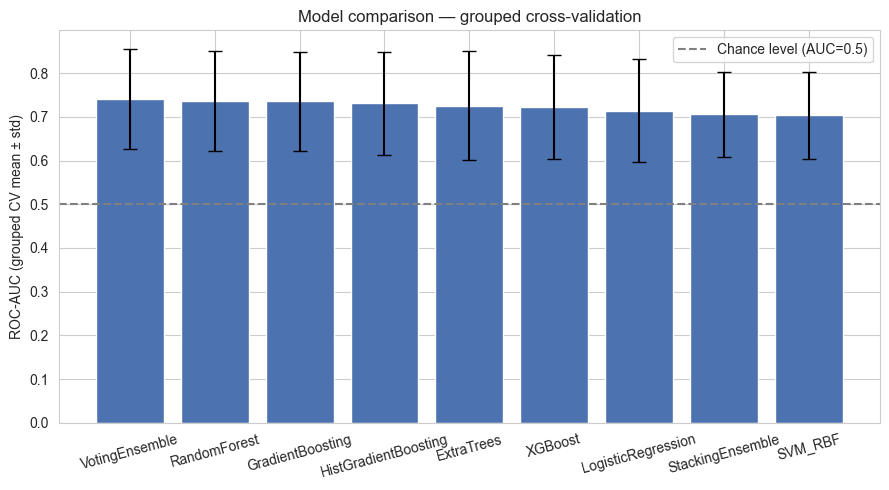

Best model by mean CV ROC-AUC: VotingEnsemble


In [9]:

fig, ax = plt.subplots(figsize=(9, 5))
metric_for_plot = "roc_auc"
means = [np.mean([m[metric_for_plot] for m in cv_results[name]]) for name in models]
stds = [np.std([m[metric_for_plot] for m in cv_results[name]]) for name in models]
order = np.argsort(means)[::-1]
names_sorted = [list(models.keys())[i] for i in order]
means_sorted = [means[i] for i in order]
stds_sorted = [stds[i] for i in order]

ax.bar(names_sorted, means_sorted, yerr=stds_sorted, capsize=5, color="#4C72B0")
ax.axhline(0.5, color="gray", linestyle="--", label="Chance level (AUC=0.5)")
ax.set_ylabel("ROC-AUC (grouped CV mean ± std)")
ax.set_title("Model comparison — grouped cross-validation")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = names_sorted[0]
print(f"Best model by mean CV ROC-AUC: {best_model_name}")


## 8. Hyperparameter tuning for the best model

The winning model from Section 7 gets a randomized hyperparameter search, still using the same
patient-grouped CV so the tuning itself can't leak either. If the **stacking or voting ensemble** won
outright, it's used as-is — the individual base models inside it were already tuned implicitly by being
selected into the top 3, and re-tuning an ensemble's internals is a fast track to overfitting the CV
folds rather than improving genuine generalization.

In [10]:

param_grids = {
    "LogisticRegression": {
        "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l2"],
    },
    "RandomForest": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [None, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
        "clf__max_features": ["sqrt", "log2"],
    },
    "ExtraTrees": {
        "clf__n_estimators": [300, 400, 600],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4],
    },
    "GradientBoosting": {
        "clf__n_estimators": [100, 200, 300],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__max_depth": [2, 3, 4],
    },
    "HistGradientBoosting": {
        "clf__max_iter": [100, 200, 300],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__max_depth": [None, 5, 10],
    },
    "SVM_RBF": {
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", 0.001, 0.01, 0.1],
    },
    "XGBoost": {
        "clf__n_estimators": [200, 300, 500],
        "clf__max_depth": [3, 4, 6],
        "clf__learning_rate": [0.01, 0.05, 0.1],
        "clf__subsample": [0.7, 0.9, 1.0],
    },
}

if best_model_name in param_grids:
    search = RandomizedSearchCV(
        models[best_model_name],
        param_distributions=param_grids[best_model_name],
        n_iter=20,
        scoring="roc_auc",
        cv=cv.split(X_train, y_train, groups_train),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
    )
    search.fit(X_train, y_train)
    print(f"Best params for {best_model_name}: {search.best_params_}")
    print(f"Best grouped-CV ROC-AUC: {search.best_score_:.3f}")
    final_model = search.best_estimator_
else:
    print(f"'{best_model_name}' is an ensemble - using it as-is (no further tuning).")
    final_model = models[best_model_name]
    final_model.fit(X_train, y_train)


'VotingEnsemble' is an ensemble - using it as-is (no further tuning).


## 9. Final evaluation on the held-out patients

This is the number that actually matters: performance on patients the model never saw in training or
tuning, at two levels of granularity —

- **Window-level**: one prediction per 2-second epoch.
- **Patient-level**: epochs for a patient are aggregated (mean predicted probability, then thresholded at
  0.5) into a single diagnosis per patient — closer to how this would actually be used, and typically more
  stable than any single window.

In [11]:

final_model.fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

window_metrics = evaluate_predictions(y_test, test_pred, test_proba)
print("=== Window-level performance on held-out patients ===")
for k, v in window_metrics.items():
    print(f"  {k:10s}: {v:.3f}")
print()
print(classification_report(y_test, test_pred, target_names=["Control", "ADHD"]))


=== Window-level performance on held-out patients ===
  accuracy  : 0.597
  precision : 0.640
  recall    : 0.702
  f1        : 0.670
  roc_auc   : 0.601
  mcc       : 0.156

              precision    recall  f1-score   support

     Control       0.52      0.45      0.48      1433
        ADHD       0.64      0.70      0.67      1997

    accuracy                           0.60      3430
   macro avg       0.58      0.58      0.58      3430
weighted avg       0.59      0.60      0.59      3430



In [12]:

results_df = pd.DataFrame({
    "patient_id": groups_test,
    "y_true": y_test,
    "proba": test_proba,
})
patient_agg = results_df.groupby("patient_id").agg(
    y_true=("y_true", "first"),
    mean_proba=("proba", "mean"),
).reset_index()
patient_agg["y_pred"] = (patient_agg["mean_proba"] >= 0.5).astype(int)

patient_metrics = evaluate_predictions(
    patient_agg["y_true"].values, patient_agg["y_pred"].values, patient_agg["mean_proba"].values
)
print("=== Patient-level performance on held-out patients ===")
for k, v in patient_metrics.items():
    print(f"  {k:10s}: {v:.3f}")
print()
print(classification_report(patient_agg["y_true"], patient_agg["y_pred"], target_names=["Control", "ADHD"]))


=== Patient-level performance on held-out patients ===
  accuracy  : 0.560
  precision : 0.562
  recall    : 0.692
  f1        : 0.621
  roc_auc   : 0.590
  mcc       : 0.113

              precision    recall  f1-score   support

     Control       0.56      0.42      0.48        12
        ADHD       0.56      0.69      0.62        13

    accuracy                           0.56        25
   macro avg       0.56      0.55      0.55        25
weighted avg       0.56      0.56      0.55        25



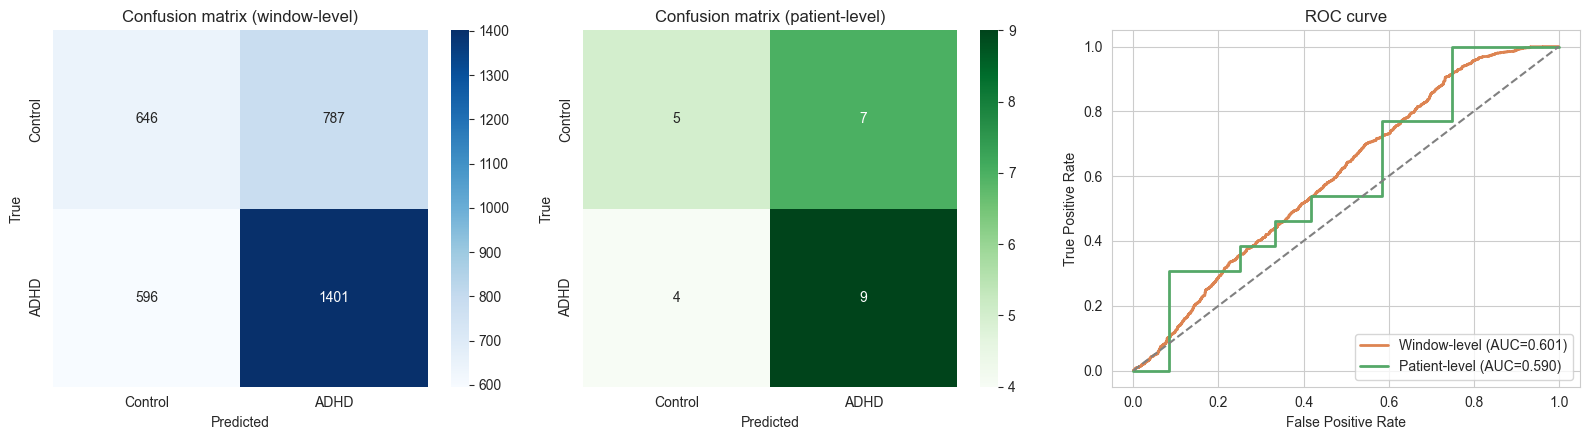

In [13]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Confusion matrix - window level
cm_win = confusion_matrix(y_test, test_pred)
sns.heatmap(cm_win, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Control", "ADHD"], yticklabels=["Control", "ADHD"])
axes[0].set_title("Confusion matrix (window-level)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# Confusion matrix - patient level
cm_pat = confusion_matrix(patient_agg["y_true"], patient_agg["y_pred"])
sns.heatmap(cm_pat, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Control", "ADHD"], yticklabels=["Control", "ADHD"])
axes[1].set_title("Confusion matrix (patient-level)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

# ROC curve (window-level)
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[2].plot(fpr, tpr, color="#DD8452", lw=2,
             label=f"Window-level (AUC={window_metrics['roc_auc']:.3f})")
fpr_p, tpr_p, _ = roc_curve(patient_agg["y_true"], patient_agg["mean_proba"])
axes[2].plot(fpr_p, tpr_p, color="#55A868", lw=2,
             label=f"Patient-level (AUC={patient_metrics['roc_auc']:.3f})")
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC curve"); axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 10. What is the model actually using? (Interpretability)

Feature importance for tree-based models (or permutation importance as a model-agnostic fallback) shows
which channels/bands drive the predictions. If the theta/beta ratio and frontal/central channels come out
near the top, that lines up with the ADHD EEG literature and is a good sign the model learned something
real rather than an artifact of preprocessing.

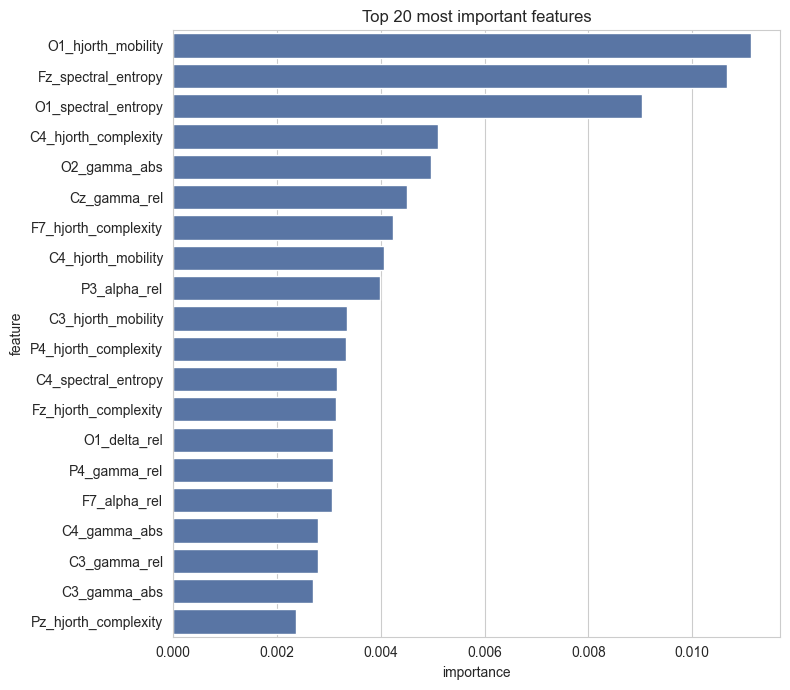

Do theta/beta ratio or band-power features from frontal/central channels rank near the top?
             feature  importance
  O1_hjorth_mobility    0.011134
 Fz_spectral_entropy    0.010668
 O1_spectral_entropy    0.009025
C4_hjorth_complexity    0.005094
        O2_gamma_abs    0.004963
        Cz_gamma_rel    0.004513
F7_hjorth_complexity    0.004245
  C4_hjorth_mobility    0.004068
        P3_alpha_rel    0.003984
  C3_hjorth_mobility    0.003356


In [14]:

from sklearn.inspection import permutation_importance

if hasattr(final_model, "named_steps") and hasattr(final_model.named_steps["clf"], "feature_importances_"):
    importances = final_model.named_steps["clf"].feature_importances_
else:
    # Ensembles (VotingClassifier/StackingClassifier) don't expose a single feature_importances_,
    # so permutation importance (model-agnostic) is used instead.
    perm = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                                   random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
    importances = perm.importances_mean

importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(8, 7))
sns.barplot(data=importance_df, y="feature", x="importance", color="#4C72B0")
plt.title("Top 20 most important features")
plt.tight_layout()
plt.show()

print("Do theta/beta ratio or band-power features from frontal/central channels rank near the top?")
print(importance_df.head(10).to_string(index=False))


## 11. Full vs. simple preprocessing — which one actually helped?

The same feature-extraction, model configuration and — importantly — the same **canonical `TRAIN_PIDS`/
`TEST_PIDS` split** from Section 2.1 are now applied to whichever pipeline wasn't used as primary, so the
two can be compared side-by-side on the same held-out patients. This directly answers whether the extra
ICA/interpolation/re-referencing work in the "full" pipeline was worth it for classification, or whether
the "simple" pipeline gets you just as far — and it also decides `BEST_PIPELINE_NAME`, the pipeline the
deep learning models and final ensemble in the next sections are built on.

In [15]:

from sklearn.base import clone

def run_pipeline_end_to_end(feat_df, model_pipeline):
    X, y, groups = get_X_y_groups(feat_df)
    tr_mask = np.isin(groups, list(TRAIN_PIDS))
    te_mask = np.isin(groups, list(TEST_PIDS))
    Xtr, Xte = X.values[tr_mask], X.values[te_mask]
    ytr, yte = y[tr_mask], y[te_mask]
    grp_te = groups[te_mask]

    model_pipeline.fit(Xtr, ytr)
    proba = model_pipeline.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    win_metrics = evaluate_predictions(yte, pred, proba)

    df = pd.DataFrame({"patient_id": grp_te, "y_true": yte, "proba": proba})
    agg = df.groupby("patient_id").agg(y_true=("y_true", "first"), mean_proba=("proba", "mean")).reset_index()
    agg["y_pred"] = (agg["mean_proba"] >= 0.5).astype(int)
    pat_metrics = evaluate_predictions(agg["y_true"].values, agg["y_pred"].values, agg["mean_proba"].values)

    return win_metrics, pat_metrics

comparison_rows = []
pipeline_patient_auc = {}
for name, feat_df in feature_cache.items():
    model_copy = clone(final_model)
    win_m, pat_m = run_pipeline_end_to_end(feat_df, model_copy)
    pipeline_patient_auc[name] = pat_m["roc_auc"]
    for level, metrics in [("window", win_m), ("patient", pat_m)]:
        row = {"pipeline": name, "level": level}
        row.update(metrics)
        comparison_rows.append(row)

pipeline_comparison_df = pd.DataFrame(comparison_rows)
BEST_PIPELINE_NAME = max(pipeline_patient_auc, key=pipeline_patient_auc.get)
print(f"Best pipeline by patient-level ROC-AUC: '{BEST_PIPELINE_NAME}' "
      f"({pipeline_patient_auc[BEST_PIPELINE_NAME]:.3f})")
pipeline_comparison_df.round(3)


Best pipeline by patient-level ROC-AUC: 'simple' (0.712)


,pipeline,level,accuracy,precision,recall,f1,roc_auc,mcc
0,full,window,0.597,0.640,0.702,0.670,0.601,0.156
1,full,patient,0.560,0.562,0.692,0.621,0.590,0.113
2,simple,window,0.618,0.666,0.690,0.678,0.650,0.209
3,simple,patient,0.680,0.632,0.923,0.750,0.712,0.397


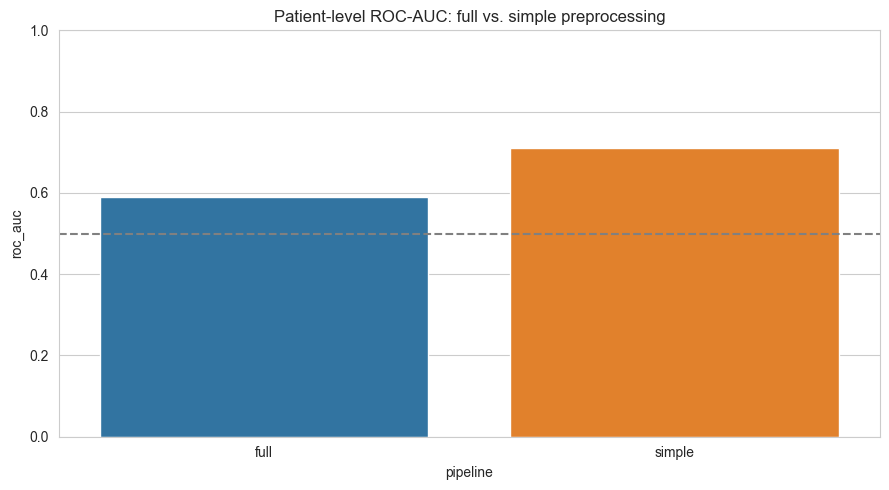

In [16]:

fig, ax = plt.subplots(figsize=(9, 5))
plot_df = pipeline_comparison_df[pipeline_comparison_df["level"] == "patient"]
sns.barplot(data=plot_df, x="pipeline", y="roc_auc", hue="pipeline", ax=ax, dodge=False, legend=False)
ax.axhline(0.5, color="gray", linestyle="--")
ax.set_title("Patient-level ROC-AUC: full vs. simple preprocessing")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


## 12. Deep learning on the raw epochs

Everything so far worked on hand-engineered features. This section trains compact deep learning models
directly on the raw 2-second windows of `BEST_PIPELINE_NAME` (chosen in Section 11), the way the two
reference notebooks did — but keeping the same discipline that made the classical results trustworthy:
strictly patient-grouped splitting and CV, an internal validation split (carved only from the *training*
patients) for early stopping so the test patients stay untouched until the very end, and light data
augmentation (small amplitude jitter and gaussian noise) to partially compensate for having only ~96
training subjects, which is genuinely small for a deep model.

Two compact architectures are tried — big transformer-style models are deliberately avoided given what
happened to the one in the reference notebook (Section 0) once evaluated honestly:

- **EEGNet-style CNN** — a small, well-established EEG architecture: a temporal convolution, then a
  depthwise convolution across channels (learns spatial filters per temporal filter), then a separable
  convolution, then a dense head. It has relatively few parameters, which matters a lot with this few
  subjects.
- **CNN + BiLSTM** — convolutional feature extraction followed by a bidirectional LSTM over time, similar
  in spirit to the more successful models in the `adhd-121-dl` reference notebook.

Both are compared via a lightweight patient-grouped CV before picking one to finalize.

In [17]:

import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import GroupShuffleSplit as _GSS

tf.random.set_seed(RANDOM_STATE)

best_d = datasets[BEST_PIPELINE_NAME]
X_epochs_all = best_d["epochs"].astype("float32")     # (n_epochs, n_channels, n_timesteps)
y_epochs_all = best_d["labels"].astype("int32")
pid_epochs_all = best_d["patient_ids"]

n_channels_dl = X_epochs_all.shape[1]
n_timesteps_dl = X_epochs_all.shape[2]

train_mask_dl = np.isin(pid_epochs_all, list(TRAIN_PIDS))
test_mask_dl = np.isin(pid_epochs_all, list(TEST_PIDS))

X_train_dl = X_epochs_all[train_mask_dl][..., np.newaxis]   # (N, ch, time, 1)
y_train_dl = y_epochs_all[train_mask_dl]
groups_train_dl = pid_epochs_all[train_mask_dl]

X_test_dl = X_epochs_all[test_mask_dl][..., np.newaxis]
y_test_dl = y_epochs_all[test_mask_dl]
groups_test_dl = pid_epochs_all[test_mask_dl]

print(f"Deep learning input shape: {X_train_dl.shape[1:]} (channels, timesteps, 1)")
print(f"Train: {len(X_train_dl)} epochs / {len(np.unique(groups_train_dl))} patients")
print(f"Test:  {len(X_test_dl)} epochs / {len(np.unique(groups_test_dl))} patients")


def augment_epochs(X, y, groups, n_aug=1, noise_std=0.03, scale_range=(0.9, 1.1), seed=RANDOM_STATE):
    # Adds light gaussian-noise + amplitude-scaling copies of the TRAINING epochs only.
    rng = np.random.RandomState(seed)
    aug_X, aug_y, aug_groups = [X], [y], [groups]
    for _ in range(n_aug):
        noise = rng.normal(0, noise_std, size=X.shape).astype("float32")
        scale = rng.uniform(scale_range[0], scale_range[1], size=(X.shape[0], 1, 1, 1)).astype("float32")
        aug_X.append(X * scale + noise)
        aug_y.append(y)
        aug_groups.append(groups)
    return np.concatenate(aug_X), np.concatenate(aug_y), np.concatenate(aug_groups)


def build_eegnet_style(n_channels, n_timesteps, f1=8, d=2, f2=16, dropout=0.4):
    inp = layers.Input(shape=(n_channels, n_timesteps, 1))
    x = layers.Conv2D(f1, (1, 32), padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.DepthwiseConv2D((n_channels, 1), depth_multiplier=d, use_bias=False,
                                depthwise_constraint=tf.keras.constraints.max_norm(1.0))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.SeparableConv2D(f2, (1, 16), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="EEGNetStyle")


def build_cnn_bilstm(n_channels, n_timesteps, dropout=0.4):
    inp = layers.Input(shape=(n_channels, n_timesteps, 1))
    x = layers.Conv2D(16, (n_channels, 5), padding="valid", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (1, 5), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    x = layers.Dropout(dropout)(x)
    # x shape: (batch, 1, time', 32) -> treat time' as sequence, 32 as feature dim
    x = layers.Reshape((x.shape[2], x.shape[3]))(x)
    x = layers.Bidirectional(layers.LSTM(32, dropout=dropout))(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    return models.Model(inp, out, name="CNN_BiLSTM")


DEEP_ARCHITECTURES = {
    "EEGNetStyle": build_eegnet_style,
    "CNN_BiLSTM": build_cnn_bilstm,
}


def compile_deep_model(builder, n_channels, n_timesteps, lr=1e-3):
    model = builder(n_channels, n_timesteps)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), "accuracy"],
    )
    return model


def train_deep_model(builder, Xtr, ytr, groups_tr, epochs=40, batch_size=64, verbose=0):
    # Carve an internal validation split from the training patients only, for early stopping.
    gss_val = _GSS(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    tr_idx, val_idx = next(gss_val.split(Xtr, ytr, groups_tr))

    Xtr_aug, ytr_aug, _ = augment_epochs(Xtr[tr_idx], ytr[tr_idx], groups_tr[tr_idx], n_aug=1)

    class_weight = {
        0: len(ytr_aug) / (2 * np.sum(ytr_aug == 0)),
        1: len(ytr_aug) / (2 * np.sum(ytr_aug == 1)),
    }

    model = compile_deep_model(builder, Xtr.shape[1], Xtr.shape[2])
    es = tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=8,
                                           restore_best_weights=True)
    model.fit(
        Xtr_aug, ytr_aug,
        validation_data=(Xtr[val_idx], ytr[val_idx]),
        epochs=epochs, batch_size=batch_size, class_weight=class_weight,
        callbacks=[es], verbose=verbose,
    )
    return model


Deep learning input shape: (15, 256, 1) (channels, timesteps, 1)
Train: 13319 epochs / 96 patients
Test:  3430 epochs / 25 patients


In [18]:

# --- Lightweight patient-grouped CV to pick the better architecture (fewer folds/epochs for speed) ---
arch_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
arch_scores = {name: [] for name in DEEP_ARCHITECTURES}

for arch_name, builder in DEEP_ARCHITECTURES.items():
    print(f"\n=== Architecture search: {arch_name} ===")
    for fold, (tr_idx, va_idx) in enumerate(arch_cv.split(X_train_dl, y_train_dl, groups_train_dl)):
        model = train_deep_model(builder, X_train_dl[tr_idx], y_train_dl[tr_idx],
                                  groups_train_dl[tr_idx], epochs=25, verbose=0)
        proba = model.predict(X_train_dl[va_idx], verbose=0).ravel()
        df = pd.DataFrame({"pid": groups_train_dl[va_idx], "y": y_train_dl[va_idx], "proba": proba})
        agg = df.groupby("pid").agg(y=("y", "first"), proba=("proba", "mean"))
        auc = roc_auc_score(agg["y"], agg["proba"])
        arch_scores[arch_name].append(auc)
        print(f"  fold {fold+1}: patient-level ROC-AUC = {auc:.3f}")
        tf.keras.backend.clear_session()

for name, scores in arch_scores.items():
    print(f"{name}: mean patient-level ROC-AUC = {np.mean(scores):.3f} (+/- {np.std(scores):.3f})")

DEEP_BEST_NAME = max(arch_scores, key=lambda n: np.mean(arch_scores[n]))
print(f"\nBest deep architecture: {DEEP_BEST_NAME}")



=== Architecture search: EEGNetStyle ===
  fold 1: patient-level ROC-AUC = 0.695

  fold 2: patient-level ROC-AUC = 0.836
  fold 3: patient-level ROC-AUC = 0.938

=== Architecture search: CNN_BiLSTM ===
  fold 1: patient-level ROC-AUC = 0.629
  fold 2: patient-level ROC-AUC = 0.836
  fold 3: patient-level ROC-AUC = 0.926
EEGNetStyle: mean patient-level ROC-AUC = 0.823 (+/- 0.099)
CNN_BiLSTM: mean patient-level ROC-AUC = 0.797 (+/- 0.124)

Best deep architecture: EEGNetStyle


In [19]:

# --- Refit the winning architecture on the full training set, evaluate on held-out patients ---
deep_model = train_deep_model(DEEP_ARCHITECTURES[DEEP_BEST_NAME], X_train_dl, y_train_dl,
                               groups_train_dl, epochs=60, verbose=1)

deep_test_proba = deep_model.predict(X_test_dl, verbose=0).ravel()
deep_test_pred = (deep_test_proba >= 0.5).astype(int)
deep_window_metrics = evaluate_predictions(y_test_dl, deep_test_pred, deep_test_proba)

deep_df = pd.DataFrame({"patient_id": groups_test_dl, "y_true": y_test_dl, "proba": deep_test_proba})
deep_patient_agg = deep_df.groupby("patient_id").agg(
    y_true=("y_true", "first"), mean_proba=("proba", "mean")
).reset_index()
deep_patient_agg["y_pred"] = (deep_patient_agg["mean_proba"] >= 0.5).astype(int)
deep_patient_metrics = evaluate_predictions(
    deep_patient_agg["y_true"].values, deep_patient_agg["y_pred"].values, deep_patient_agg["mean_proba"].values
)

print(f"=== {DEEP_BEST_NAME} — window-level (held-out patients) ===")
for k, v in deep_window_metrics.items():
    print(f"  {k:10s}: {v:.3f}")
print(f"\n=== {DEEP_BEST_NAME} — patient-level (held-out patients) ===")
for k, v in deep_patient_metrics.items():
    print(f"  {k:10s}: {v:.3f}")


Epoch 1/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.6525 - auc: 0.7204 - loss: 0.6087 - val_accuracy: 0.5926 - val_auc: 0.7964 - val_loss: 0.5989
Epoch 2/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7933 - auc: 0.8772 - loss: 0.4349 - val_accuracy: 0.7784 - val_auc: 0.7868 - val_loss: 0.5612
Epoch 3/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8323 - auc: 0.9144 - loss: 0.3692 - val_accuracy: 0.7708 - val_auc: 0.8075 - val_loss: 0.5900
Epoch 4/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8558 - auc: 0.9329 - loss: 0.3290 - val_accuracy: 0.7890 - val_auc: 0.8025 - val_loss: 0.6710
Epoch 5/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.8703 - auc: 0.9450 - loss: 0.2993 - val_accuracy: 0.7744 - val_auc: 0.8198 - val_loss: 0.6230
Epoch 6/60
355/355 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.8815 - auc: 0.9527 - loss: 0.2777 - val_accuracy: 0.7527 - val_auc: 0.8166 - val_loss: 0.6500
Epoch 7/60
355/355 ━━━━━━━━━

## 13. Stacking the classical model with the deep model

The classical feature-based model and the deep model likely make different kinds of mistakes — one sees
hand-engineered spectral summaries, the other sees the raw waveform. **Stacking** them can pick up on that
complementarity: a small logistic-regression meta-learner is trained on each model's **out-of-fold**
prediction for every training patient (never on a prediction a model made about data it was trained on),
then at test time both models' held-out predictions are combined through that same meta-learner. This is
the most legitimate way left to push performance further without crossing into leakage.

In [20]:

best_feat_df = feature_cache[BEST_PIPELINE_NAME]
X_best, y_best, groups_best = get_X_y_groups(best_feat_df)

# Same boolean masks (built from the same underlying patient_ids array/order) keep the classical
# features and the raw epochs perfectly row-aligned.
X_train_best, X_test_best = X_best.values[train_mask_dl], X_best.values[test_mask_dl]
y_train_best, y_test_best = y_best[train_mask_dl], y_best[test_mask_dl]
groups_train_best, groups_test_best = groups_best[train_mask_dl], groups_best[test_mask_dl]

assert np.array_equal(y_train_best, y_train_dl) and np.array_equal(groups_train_best, groups_train_dl), \
    "Classical features and raw epochs are not row-aligned - stacking would silently mix up labels."

stack_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classical_oof = np.zeros(len(y_train_best))
deep_oof = np.zeros(len(y_train_best))

for fold, (tr_idx, va_idx) in enumerate(stack_cv.split(X_train_best, y_train_best, groups_train_best)):
    print(f"Stacking fold {fold + 1}/5...")

    classical_fold = clone(final_model)
    classical_fold.fit(X_train_best[tr_idx], y_train_best[tr_idx])
    classical_oof[va_idx] = classical_fold.predict_proba(X_train_best[va_idx])[:, 1]

    deep_fold = train_deep_model(DEEP_ARCHITECTURES[DEEP_BEST_NAME], X_train_dl[tr_idx],
                                  y_train_dl[tr_idx], groups_train_dl[tr_idx], epochs=25, verbose=0)
    deep_oof[va_idx] = deep_fold.predict(X_train_dl[va_idx], verbose=0).ravel()
    del deep_fold  # avoid clear_session() here - it would risk invalidating deep_model, needed later

meta_X_train = np.column_stack([classical_oof, deep_oof])
meta_model = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)
meta_model.fit(meta_X_train, y_train_best)
print(f"\nMeta-learner weights (classical, deep): {meta_model.coef_[0]}")


Stacking fold 1/5...
Stacking fold 2/5...
Stacking fold 3/5...
Stacking fold 4/5...
Stacking fold 5/5...

Meta-learner weights (classical, deep): [0.40109154 3.0978855 ]


In [21]:

# --- Final blended prediction on the held-out test patients ---
classical_full = clone(final_model)
classical_full.fit(X_train_best, y_train_best)
classical_test_proba_best = classical_full.predict_proba(X_test_best)[:, 1]

meta_X_test = np.column_stack([classical_test_proba_best, deep_test_proba])
blended_proba = meta_model.predict_proba(meta_X_test)[:, 1]
blended_pred = (blended_proba >= 0.5).astype(int)

blended_window_metrics = evaluate_predictions(y_test_best, blended_pred, blended_proba)

blend_df = pd.DataFrame({"patient_id": groups_test_best, "y_true": y_test_best, "proba": blended_proba})
blend_patient_agg = blend_df.groupby("patient_id").agg(
    y_true=("y_true", "first"), mean_proba=("proba", "mean")
).reset_index()
blend_patient_agg["y_pred"] = (blend_patient_agg["mean_proba"] >= 0.5).astype(int)
blended_patient_metrics = evaluate_predictions(
    blend_patient_agg["y_true"].values, blend_patient_agg["y_pred"].values,
    blend_patient_agg["mean_proba"].values
)

# --- Head-to-head summary: classical alone vs. deep alone vs. stacked ensemble ---
classical_window_metrics_best = evaluate_predictions(
    y_test_best, (classical_test_proba_best >= 0.5).astype(int), classical_test_proba_best
)
classical_pat_df = pd.DataFrame({"patient_id": groups_test_best, "y_true": y_test_best,
                                  "proba": classical_test_proba_best})
classical_pat_agg = classical_pat_df.groupby("patient_id").agg(
    y_true=("y_true", "first"), mean_proba=("proba", "mean")
).reset_index()
classical_pat_agg["y_pred"] = (classical_pat_agg["mean_proba"] >= 0.5).astype(int)
classical_patient_metrics_best = evaluate_predictions(
    classical_pat_agg["y_true"].values, classical_pat_agg["y_pred"].values, classical_pat_agg["mean_proba"].values
)

summary_rows = []
for approach, win_m, pat_m in [
    ("Classical (best model)", classical_window_metrics_best, classical_patient_metrics_best),
    (f"Deep learning ({DEEP_BEST_NAME})", deep_window_metrics, deep_patient_metrics),
    ("Stacked ensemble", blended_window_metrics, blended_patient_metrics),
]:
    for level, m in [("window", win_m), ("patient", pat_m)]:
        row = {"approach": approach, "level": level}
        row.update(m)
        summary_rows.append(row)

final_comparison_df = pd.DataFrame(summary_rows)
final_comparison_df.round(3)


,approach,level,accuracy,precision,recall,f1,roc_auc,mcc
0,Classical (best model),window,0.618,0.666,0.690,0.678,0.650,0.209
1,Classical (best model),patient,0.680,0.632,0.923,0.750,0.712,0.397
2,Deep learning (EEGNetStyle),window,0.769,0.824,0.768,0.795,0.840,0.534
3,Deep learning (EEGNetStyle),patient,0.760,0.769,0.769,0.769,0.872,0.519
4,Stacked ensemble,window,0.755,0.824,0.736,0.777,0.835,0.510
5,Stacked ensemble,patient,0.800,0.833,0.769,0.800,0.859,0.603


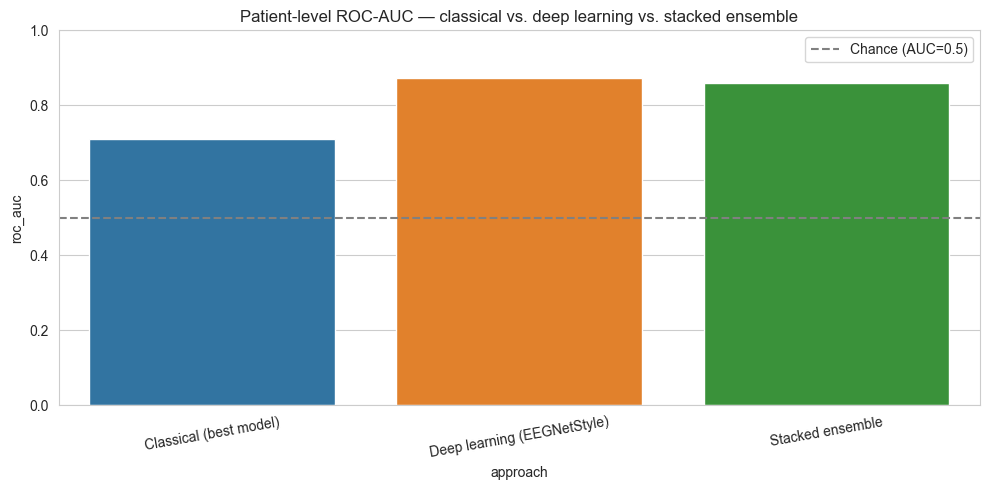

              precision    recall  f1-score   support

     Control       0.77      0.83      0.80        12
        ADHD       0.83      0.77      0.80        13

    accuracy                           0.80        25
   macro avg       0.80      0.80      0.80        25
weighted avg       0.80      0.80      0.80        25



In [22]:

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = final_comparison_df[final_comparison_df["level"] == "patient"]
sns.barplot(data=plot_df, x="approach", y="roc_auc", hue="approach", ax=ax, dodge=False, legend=False)
ax.axhline(0.5, color="gray", linestyle="--", label="Chance (AUC=0.5)")
ax.set_title("Patient-level ROC-AUC — classical vs. deep learning vs. stacked ensemble")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
plt.legend()
plt.tight_layout()
plt.show()

print(classification_report(blend_patient_agg["y_true"], blend_patient_agg["y_pred"],
                             target_names=["Control", "ADHD"]))


## 14. Save the final model and predictions

Saves whichever approach won in Section 13's head-to-head table (classical / deep / stacked) — the
comparison there is what should decide which artifact you actually report as "the model" in your writeup,
not an assumption baked in here.

In [23]:

import joblib

joblib.dump(final_model, "adhd_classical_model.joblib")
deep_model.save("adhd_deep_model.keras")
joblib.dump(meta_model, "adhd_stacking_meta_model.joblib")

blend_patient_agg.to_csv("adhd_patient_level_predictions_stacked.csv", index=False)
blend_df.to_csv("adhd_window_level_predictions_stacked.csv", index=False)
final_comparison_df.to_csv("adhd_model_comparison_summary.csv", index=False)

print("Saved:")
print("  - adhd_classical_model.joblib        (best classical sklearn Pipeline/ensemble)")
print("  - adhd_deep_model.keras              (best deep learning model)")
print("  - adhd_stacking_meta_model.joblib    (logistic-regression meta-learner)")
print("  - adhd_patient_level_predictions_stacked.csv")
print("  - adhd_window_level_predictions_stacked.csv")
print("  - adhd_model_comparison_summary.csv  (classical vs deep vs stacked, window & patient level)")


Saved:
  - adhd_classical_model.joblib        (best classical sklearn Pipeline/ensemble)
  - adhd_deep_model.keras              (best deep learning model)
  - adhd_stacking_meta_model.joblib    (logistic-regression meta-learner)
  - adhd_patient_level_predictions_stacked.csv
  - adhd_window_level_predictions_stacked.csv
  - adhd_model_comparison_summary.csv  (classical vs deep vs stacked, window & patient level)
